# 데이터셋 불러오기

In [261]:
import pandas as pd

df = pd.read_csv('C:/Users/Administrator/Dogyeom(2023.01.01)/KIST_intern/Task1/Control_Nuclear_Spins/initialize13Cspin/file/testdata.csv')
df

,Al,Ap,N,x,z,fun
0,3.484993,0.888483,13.0,1.752885,1.085551,0.032390
1,3.390258,1.763503,9.0,3.184325,2.548000,0.094200
2,1.033954,1.358603,9.0,1.463811,1.138441,0.040758
3,4.255130,0.605356,17.0,2.920000,1.788500,0.046560
4,4.746024,1.083821,13.0,2.770525,1.185844,0.026307
...,...,...,...,...,...,...
17195,3.128535,1.869217,9.0,2.544723,1.089060,0.075003
17196,2.884187,1.227778,9.0,0.371164,0.164950,0.044997
17197,1.378197,0.897630,9.0,0.449094,0.207785,0.039260
17198,1.988062,0.924715,9.0,2.954908,1.260862,0.087043


## 데이터셋 분류

In [262]:
y = df[['N', 'x', 'z']]
y

,N,x,z
0,13.0,1.752885,1.085551
1,9.0,3.184325,2.548000
2,9.0,1.463811,1.138441
3,17.0,2.920000,1.788500
4,13.0,2.770525,1.185844
...,...,...,...
17195,9.0,2.544723,1.089060
17196,9.0,0.371164,0.164950
17197,9.0,0.449094,0.207785
17198,9.0,2.954908,1.260862


In [263]:
X = df[['Al', 'Ap']]
X

,Al,Ap
0,3.484993,0.888483
1,3.390258,1.763503
2,1.033954,1.358603
3,4.255130,0.605356
4,4.746024,1.083821
...,...,...
17195,3.128535,1.869217
17196,2.884187,1.227778
17197,1.378197,0.897630
17198,1.988062,0.924715


## 데이터 학습/테스트 구분

In [264]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, random_state=100)

# 학습 모델

## KNN regression

In [265]:
from sklearn.neighbors import KNeighborsRegressor

kn = KNeighborsRegressor(n_neighbors = 10, weights = "distance")
kn.fit(X_train, y_train)

KNeighborsRegressor(n_neighbors=10, weights='distance')

In [266]:
y_kn_train_pred = kn.predict(X_train)
y_kn_test_pred = kn.predict(X_test)

# Figure

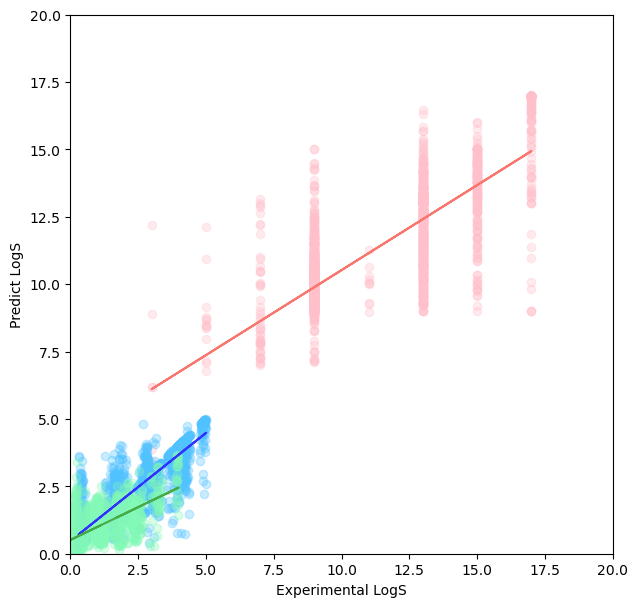

In [267]:
import matplotlib.pyplot as plt
import numpy as np


yn = y_test['N']
ynt = y_kn_test_pred[:,0]

yx = y_test['x']
yxt = y_kn_test_pred[:,1]

yz = y_test['z']
yzt = y_kn_test_pred[:,2]

plt.figure(figsize=(7,7))
plt.scatter(x=yn, y=ynt, c="#FFC0CB" ,alpha=0.3)

plt.scatter(x=yx, y=yxt, c="#50C2FF" ,alpha=0.3)

plt.scatter(x=yz, y=yzt, c="#82F9B7" ,alpha=0.3)

nn = np.polyfit(yn, ynt, 1)
pn = np.poly1d(nn)

xx = np.polyfit(yx, yxt, 1)
px = np.poly1d(xx)

zz = np.polyfit(yz, yzt, 1)
pz = np.poly1d(zz)

plt.plot(yn, pn(yn), '#F8766D')
plt.plot(yx, px(yx), '#3232FF')
plt.plot(yz, pz(yz), '#46AA46')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')
plt.ylim(0, 20)
plt.xlim(0, 20)
plt.show()

In [268]:
from sklearn.metrics import mean_squared_error, r2_score

# knn_train_mse = mean_squared_error(yn_train, yn_kn_train_pred)
# knn_train_r2 = r2_score(yn_train, yn_kn_train_pred)

knn_test_mse = mean_squared_error(yn, ynt)
knn_test_r2 = r2_score(yn, ynt)

# knx_train_mse = mean_squared_error(yx_train, yx_kn_train_pred)
# knx_train_r2 = r2_score(yx_train, yx_kn_train_pred)

knx_test_mse = mean_squared_error(yx, yxt)
knx_test_r2 = r2_score(yx, yxt)

# knz_train_mse = mean_squared_error(yz_train, yz_kn_train_pred)
# knz_train_r2 = r2_score(yz_train, yz_kn_train_pred)

knz_test_mse = mean_squared_error(yz, yzt)
knz_test_r2 = r2_score(yz, yzt)

In [269]:
# print('KNN MSE (Train): ', knn_train_mse)
# print('KNN R2 (Train): ', knn_train_r2)
print('KNN MSE (Test): ', knn_test_mse)
print('KNN R2 (Test): ', knn_test_r2)
print(' ')
# print('KNX MSE (Train): ', knx_train_mse)
# print('KNX R2 (Train): ', knx_train_r2)
print('KNX MSE (Test): ', knx_test_mse)
print('KNX R2 (Test): ', knx_test_r2)
print(' ')
# print('KNZ MSE (Train): ', knz_train_mse)
# print('KNZ R2 (Train): ', knz_train_r2)
print('KNZ MSE (Test): ', knz_test_mse)
print('KNZ R2 (Test): ', knz_test_r2)

KNN MSE (Test):  2.7859442706114885
KNN R2 (Test):  0.622882020749103
 
KNX MSE (Test):  0.388787590903104
KNX R2 (Test):  0.7959081601687377
 
KNZ MSE (Test):  0.4076842110539949
KNZ R2 (Test):  0.43996329780354637


# 실험하기

## 기본 설정

In [289]:
from toqito.channels import partial_trace
from qutip import *
from PIL import Image
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from scipy import linalg
import math
import matplotlib.pyplot as plt
from scipy import optimize
import random
from math import *
import pandas as pd
import time
from datetime import datetime as dt                         # 시간을 출력하기 위한 라이브러리  

def UO(B1,B2,a,D1,D2):
    i   = 1j
    gamma = 2*pi*2.8
    D     = 2870
    UA = np.array([[(B2**2+B1**2*cos(a))/(B1**2+B2**2), -i*B1*(e**(-i*D1))*sin(a)/sqrt(B1**2+B2**2), ((-1+cos(a))*B1*B2*(e**(-i*(D1-D2))))/(B1**2+B2**2)],
            [-i*B1*(e**(i*D1))*sin(a)/sqrt(B1**2+B2**2), cos(a), -i*B2*(e**(i*D2))*sin(a)/sqrt(B1**2+B2**2)],
            [((-1+cos(a))*B1*B2*e**(i*(D1-D2)))/(B1**2+B2**2), -i*B2*(e**(-i*D2))*sin(a)/sqrt(B1**2+B2**2), (B1**2+B2**2*cos(a))/(B1**2+B2**2)]])
    return UA

i   = 1j #1j
sx  = 1/sqrt(2)*np.array([[0, 1, 0],[1, 0, 1], [0, 1, 0]])
sy  = 1/sqrt(2)/i*np.array([[0, 1, 0], [-1, 0, 1],[0, -1, 0]])
sz  = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
#sz  = [1, 0, 0; 0, -1, 0; 0, 0, 0]
I   = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
#Gellman matrix
Sx  = np.array([[0, 0, 1],[0, 0, 0], [1, 0, 0]])
Sy  = np.array([[0, 0, -i],[0, 0, 0], [i, 0, 0]])
Sz  = np.array([[1, 0, 0],[0, 0, 0], [0, 0, -1]])
# Rotation matrix projected into 2 level system
Sxp  = np.array([[0, 1, 0], [1, 0, 0], [0, 0, 0]])
Sxm  = np.array([[0, 0, 0], [0, 0, 1], [0, 1, 0]])
Syp  = 1/i*np.array([[0, 1, 0], [-1, 0, 0], [0, 0, 0]])
Sym  = 1/i*np.array([[0, 0, 0], [0, 0, 1], [0, -1, 0]])
Szp  = np.array([[1, 0, 0], [0, -1, 0], [0, 0, 0]])
# Pauli basis for 13C nuclear spin
Ix  = 1/2*np.array([[0, 0, 1], [0, 0, 0], [1, 0, 0]])   
Iy  = 1/2/i*np.array([[0, 0, 1], [0, 0, 0], [-1, 0, 0]])
Iz  = np.array([[1, 0, 0], [0, 0, 0], [0, 0, -1]])
 

# Define sweep parameters
Sweep = 1001
N = Sweep
B = 403 #[G] magnetic field

    

# 13C nuclear spin parameters
gammaN = 2*pi*1.071e-3 #[MHz/G]
T = 5; # sweep tau [us]
t = np.linspace(0,T,N)
n = 32; # number of pi pulses

## Define gate operations
# Single Q ms=+1
U090xp = UO(1,0,pi/4,0,0)
U090xmp = UO(1,0,-pi/4,0,0)
U090yp = UO(1,0,pi/4,pi/2,0)
U180yp = UO(1,0,pi/2,pi,0)
U090ymp = UO(1,0,-pi/4,pi/2,0)
U180xp = UO(1,0,pi/2,0,0)
U180xmp = UO(1,0,-pi/2,0,0)

#Single Q ms=-1
U090xm = UO(0,1,pi/4,0,0)
U090xmm = UO(0,1,-pi/4,0,0)
U180xm = UO(0,1,pi/2,0,0)
U180xmm = UO(0,1,pi/2,0,0)
#사용 안됨?

# Define initial state of the system (스핀상태)

irho_p = np.array([[1,0,0],[0,0,0],[0,0,0]]) #;0,0,0;0,0,0]

irho_m = np.array([[0,0,0],[0,0,0],[0,0,1]]) #0,0,0;0,0,1]

irho_z = np.array([[0,0,0],[0,1,0],[0,0,0]]) #0,1,0;0,0,0]

irho_mix = np.array([[1/2,0,0],[0,1/2,0],[0,0,0]])

irho_Z = np.array([[0,0,0],[0,0,0],[0,0,1]])

irho_MIX = np.array([[1/2,0,0],[0,0,0],[0,0,1/2]])

#rotation operator(not use at this code)
def Rx(theta):
    Rx = e**(1j*theta/2*sx)
    return Rx

def Ry(theta):
    Ry = e**(1j*theta/2*sy)
    return Ry

def Rz(phi):
    Rz = e**(1j*phi/2*sz)
    return Rz 

irho = np.kron(irho_p,irho_MIX)

## 수직/수평값 지정

In [290]:
Al = 2*math.pi*0.3
Ap = 2*math.pi*0.3

AAin = pd.DataFrame([[Al, Ap]], columns=['Al', 'Ap'])

In [291]:
AA_predict = kn.predict(AAin)
AAdata = np.zeros((1,3))
AAdata[0][1] = AA_predict[0][0]
AAdata[0][0] = AA_predict[0][1]
AAdata[0][2] = AA_predict[0][2]

AAdata = pd.DataFrame(AAdata, columns=['Al', 'Ap', 'Aa'])
AAdata

,Al,Ap,Aa
0,1.777613,10.64636,0.335156


In [292]:
ham = Al*np.kron(sz,Iz) + Ap*np.kron(sz,Ix) + B*gammaN*np.kron(I,Iz)
eigvals = np.linalg.eigh(ham)[0] # diagonalizing the Hamiltonian 
eigvecs = -1*np.linalg.eigh(ham)[1]
E = np.diag(eigvals)             # exponent of eigenvalues
U_H= eigvecs.conj().T  

xx=0
yy=0
zz=0
vari = AAdata
def problem(vari):
    #for e Ry(pi/2)
    rho1 = np.kron(U090yp,I)@irho@(np.kron(U090yp,I).conj().T)                              # Ry 90도

    #for N Rx(pi/2)
    U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
    U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
    rho2=U_e2@rho1@(U_e2.conj().T)                                                          # first tau/2
    for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
        rho2 = U_e@np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
    rho3 = U_e2 @ np.kron(U180xp,I) @ rho2 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

    #for e Rx(pi/2)
    rho4 = np.kron(U090xp,I)@rho3@(np.kron(U090xp,I).conj().T)                              # Rx 90도

    #for N Rz(pi/2)
    U_e2=(U_H.conj().T)@(linalg.expm(-i*E*vari[2]/2)@U_H)                                   # for tau/2
    U_e=(U_H.conj().T)@(linalg.expm(-i*E*vari[2])@U_H)                                      # for tau/2
    rho5=U_e2@rho4@(U_e2.conj().T)                                                          # first tau/2
    for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
        rho5 = U_e@np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
    rho6 = U_e2 @ np.kron(U180xp,I) @ rho5 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

    #for N Rx(pi/2)
    U_e2=(U_H.conj().T)@(linalg.expm(-i*E* vari[0]/2)@U_H)                                  # for tau/2
    U_e=(U_H.conj().T)@(linalg.expm(-i*E* vari[0])@U_H)                                     # for tau
    rho7=U_e2@rho6@(U_e2.conj().T)                                                          # first tau/2
    for k in range(1,2*math.trunc(vari[1])):                                                # N과 tau를 N개 생성
        rho7 = U_e@np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e.conj().T) # N & tau
    rho8 = U_e2 @ np.kron(U180xp,I) @ rho7 @ (np.kron(U180xp,I).conj().T) @ (U_e2.conj().T) # last N & tau/2

    # projection&trace
    xob = (np.trace(Sxp@partial_trace(rho8,2))).real # for e spin
    yob = (np.trace(Syp@partial_trace(rho8,2))).real 
    zob = (np.trace(Szp@partial_trace(rho8,2))).real

    xx = (np.trace(Ix@partial_trace(rho8,1))).real # for N spin
    yy = (np.trace(Iy@partial_trace(rho8,1))).real
    zz = (np.trace(Iz@partial_trace(rho8,1))).real
    
    print(xx,yy,zz)

    cost = np.abs(0-xx)+np.abs(0-yy)+np.abs(1-zz)
    return cost

output = []

tolN = 1e-3 #tolerance
tolS = 1e-10 #tolerance

tau = AA_predict[0][1]

In [293]:
bounds = [(0.85*tau, 1.15*tau), (1.0, 17.0), (0.05*tau, 0.8*tau)]

## 결과 확인

In [294]:
res = optimize.minimize(problem, AAdata, bounds=bounds ,method='Nelder-Mead',options={'xtol':tolN,'ftol':tolN}) #Nelder-Mead method

-3.1106243395658104e-05 -7.705615535309344e-05 0.00035218668453307345
-0.00011046216885113877 0.00036218636253964416 -0.002860503800861225
-0.008244402221617658 0.011408621808887316 -0.035792144546157756
-3.4981907063579855e-05 0.00011233696891256616 0.0004967395500592442
-0.0005849609817371003 0.002717834611226209 0.008366403515389975
0.001933003708854351 0.000922965198436234 -0.0026981792708062335
-0.0008975958216585076 0.0021390887149253038 0.0032314049429979508
-0.01583573693281492 -0.005663184021098541 -0.052069202227313816
-0.012615392759326738 -0.003584429887855768 -0.06275613708258632
-0.0013385162588900011 0.0025817559695075765 -0.01618320325860967
-0.0022982284222205322 0.0018699607561367937 -0.021273356810765365
-0.000492485629424437 0.003042234984597687 0.006364598455490311
-0.0018899685371299687 0.00015160621372537278 -0.007472695722078593
-0.015797007270411466 -0.0026828841879404583 -0.09062783020132315
-6.515200375466126e-07 -1.0214975012731476e-05 1.7714567368931622e-05

### Nelder-Mead

In [295]:
res['x'][1] = round(res['x'][1])
output.append(res)

output

[ final_simplex: (array([[ 1.84357451, 10.        ,  0.33247881],
        [ 1.84357623, 10.33759754,  0.33248424],
        [ 1.84357654, 10.33903374,  0.33246934],
        [ 1.84357664, 10.33891862,  0.33246944]]), array([0.92380441, 0.92380462, 0.92380465, 0.92380465]))
            fun: 0.9238044109408626
        message: 'Optimization terminated successfully.'
           nfev: 125
            nit: 63
         status: 0
        success: True
              x: array([ 1.84357451, 10.        ,  0.33247881])]

In [287]:
res4 = optimize.shgo(problem,bounds=bounds,iters=4,options={'xtol':tolS,'ftol':tolS}) #SHGO method

0.0033293976670298146 0.0004686577226195388 -0.031856501220885014
-0.0022330630419936737 0.0006248459587723035 -0.029150580789519154
0.001542547372058594 0.00029107931705092856 0.013783929283429863
0.0020921052857819124 0.0020429160385355347 0.014649861627395178
0.009050927444192593 0.0013962294181877576 0.04574216627595612
-0.0004415203092810434 2.9116829461765803e-05 0.003727310989661503
-0.0004560406472526417 -2.4081884467432035e-06 0.011420801621009002
0.0006050347400760672 5.010088372552068e-06 -0.011197121396843868
-0.004223636007567537 1.420430212607099e-06 -0.018885710668655076
-1.332457583402098e-06 1.1339967876027501e-05 2.760106446064725e-06
0.000309408163088519 0.0022930992732106466 -0.007507817177363485
-1.9261679247276932e-07 -5.122844799084619e-06 -6.100098493250217e-05
0.0005505096747338584 -0.0014443989664577432 -0.0013228685592768241
0.0005475575912932511 0.002881658253616719 0.01116604758930434
-0.002760424710840372 0.0016468007027511476 -0.017265873641106766
-0.0092

In [288]:
output2 = []
res4['x'][1] = round(res4['x'][1])
output2.append(res4)
output2

[     fun: 0.7849405803071722
     funl: array([0.78494058, 0.83088752, 0.84699818, 0.88078303, 0.89344883,
        0.90329542, 0.92313805, 0.93374944, 0.95865506, 0.96030989,
        0.96913799, 0.98238313, 0.98843541, 0.99176575])
  message: 'Optimization terminated successfully.'
     nfev: 1195
      nit: 4
    nlfev: 1006
    nlhev: 0
    nljev: 149
  success: True
        x: array([1.90817921, 5.        , 0.42122887])
       xl: array([[ 1.90817921,  5.        ,  0.42122887],
        [ 2.0442554 ,  9.        ,  0.09039028],
        [ 2.0442554 ,  9.        ,  0.75263029],
        [ 1.70109178,  7.        ,  1.27606289],
        [ 2.0442554 , 13.        ,  1.42209071],
        [ 1.84261417, 15.        ,  1.25550044],
        [ 1.64075516,  5.        ,  0.42762571],
        [ 1.9775949 , 17.        ,  0.92213695],
        [ 1.9068933 ,  5.        ,  1.42209071],
        [ 1.56471169, 11.        ,  0.26229085],
        [ 1.51108367, 13.        ,  1.0844559 ],
        [ 1.58610007,  

In [279]:
print(res['x'])
print(" ")
print(res4['x'])

[ 1.67871349 10.          0.41287747]
 
[1.39239165 5.         0.97082749]
